# Hapur House Price Prediction - Corrected Workflow

This notebook rebuilds the original project using a leakage-safe regression workflow aligned with `ML_Workflow.md`.

## Mistakes in the original notebook

- Categorical encoding was done on the full dataset before the train/test split, which leaks test-set information into training.
- `location` was target-encoded with `groupby(location)[price].mean()` on the same full dataset. That directly injects target information into a feature.
- The notebook imported unused preprocessing classes and even imported `RandomForestClassifier` for a regression task.
- Inference required manually one-hot encoded columns instead of allowing predictions from raw house details.
- There was no model comparison or cross-validation before choosing the final model.

## What this version fixes

- Split first, then fit preprocessing only on training data.
- Use a `ColumnTransformer` and `Pipeline` so training and inference use the same steps.
- Compare simple regression baselines with cross-validation.
- Predict from raw categorical values such as `location`, `property_type`, and `furnishing`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("hapur_house_price_dataset.csv")
df.head()

,location,gaj,bhk,bath,balcony,age,floor,total_floor,property_type,furnishing,price
0,Gandhi Ganj,152,4,1,2,10,4,5,Villa,Furnished,5055168
1,Vijay Nagar,152,2,1,2,10,2,3,Builder Floor,Unfurnished,4667176
2,Pilkhuwa Road,201,3,2,0,1,3,5,Villa,Furnished,5059033
3,Kothi Gate,241,4,1,0,11,1,3,Villa,Furnished,6611436
4,Gandhi Ganj,285,1,1,0,9,3,5,Builder Floor,Furnished,5503865


In [27]:
validation_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique()
})

print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
display(validation_summary)
display(df["price"].describe().to_frame().T)

Shape: (1000, 11)
Duplicate rows: 0


,dtype,missing_values,unique_values
location,object,0,16
gaj,int64,0,331
bhk,int64,0,5
bath,int64,0,5
balcony,int64,0,4
age,int64,0,20
floor,int64,0,5
total_floor,int64,0,5
property_type,object,0,4
furnishing,object,0,3


,count,mean,std,min,25%,50%,75%,max
price,1000.0,6713836.855,3.282027e+06,408900.0,3950262.0,6448787.5,9056577.0,15628960.0


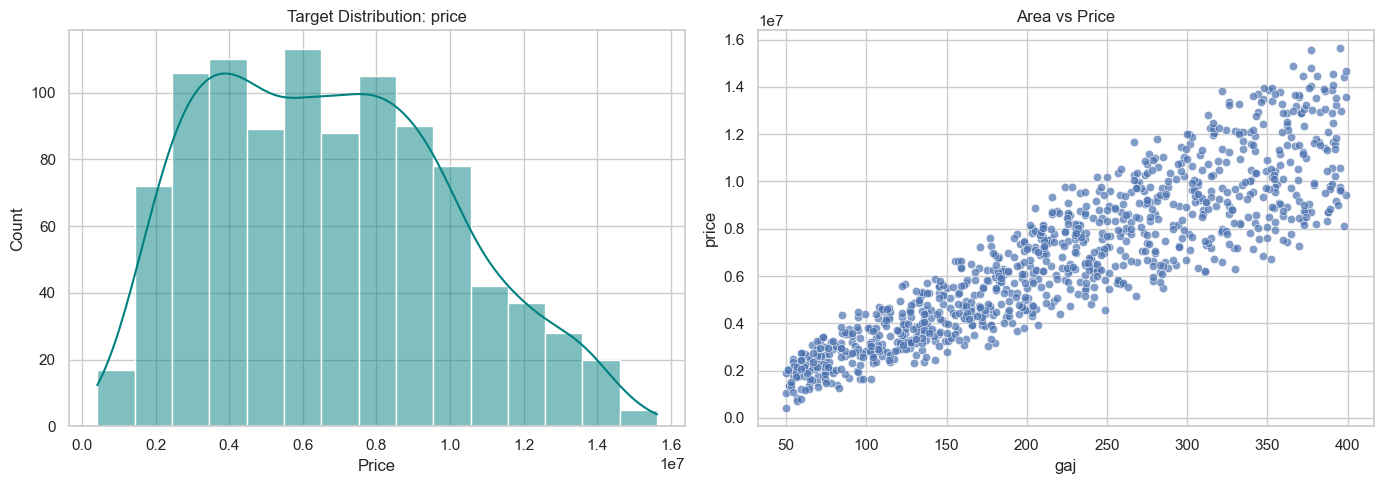

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["price"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Target Distribution: price")
axes[0].set_xlabel("Price")

sns.scatterplot(data=df, x="gaj", y="price", ax=axes[1], alpha=0.7)
axes[1].set_title("Area vs Price")
axes[1].set_xlabel("gaj")
axes[1].set_ylabel("price")

plt.tight_layout()

In [7]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Numeric features: ['gaj', 'bhk', 'bath', 'balcony', 'age', 'floor', 'total_floor']
Categorical features: ['location', 'property_type', 'furnishing']
Train shape: (800, 10)
Test shape: (200, 10)


In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

candidate_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
comparison_rows = []

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    cv_mae = -cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    ).mean()

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    comparison_rows.append({
        "model": model_name,
        "cv_mae": cv_mae,
        "test_mae": mean_absolute_error(y_test, predictions),
        "test_rmse": np.sqrt(mean_squared_error(y_test, predictions)),
        "test_r2": r2_score(y_test, predictions)
    })

results = pd.DataFrame(comparison_rows).sort_values(by=["cv_mae", "test_mae"])
results

,model,cv_mae,test_mae,test_rmse,test_r2
1,Ridge,1.106945e+06,1.128812e+06,1.454866e+06,0.799113
0,LinearRegression,1.107537e+06,1.129602e+06,1.456293e+06,0.798719
2,RandomForestRegressor,1.133744e+06,1.183608e+06,1.524843e+06,0.779324


### Final model choice

Ridge is selected as the final model because it gives the best cross-validated MAE while keeping the pipeline simple and stable.

In [11]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

final_metrics = pd.Series({
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R2": r2_score(y_test, y_pred)
})
final_metrics

MAE     1.128812e+06
RMSE    1.454866e+06
R2      7.991132e-01
dtype: float64

,actual_price,predicted_price,error,absolute_error
0,4906660,3.822126e+06,1.084534e+06,1.084534e+06
1,1861527,2.056033e+06,-1.945062e+05,1.945062e+05
2,4833008,5.840785e+06,-1.007777e+06,1.007777e+06
3,5377958,4.725267e+06,6.526915e+05,6.526915e+05
4,12999184,1.164064e+07,1.358542e+06,1.358542e+06
5,8434262,7.733938e+06,7.003235e+05,7.003235e+05
6,8167140,6.706546e+06,1.460594e+06,1.460594e+06
7,4000610,4.200502e+06,-1.998920e+05,1.998920e+05
8,4413984,3.259825e+06,1.154159e+06,1.154159e+06
9,3765970,4.307704e+06,-5.417344e+05,5.417344e+05


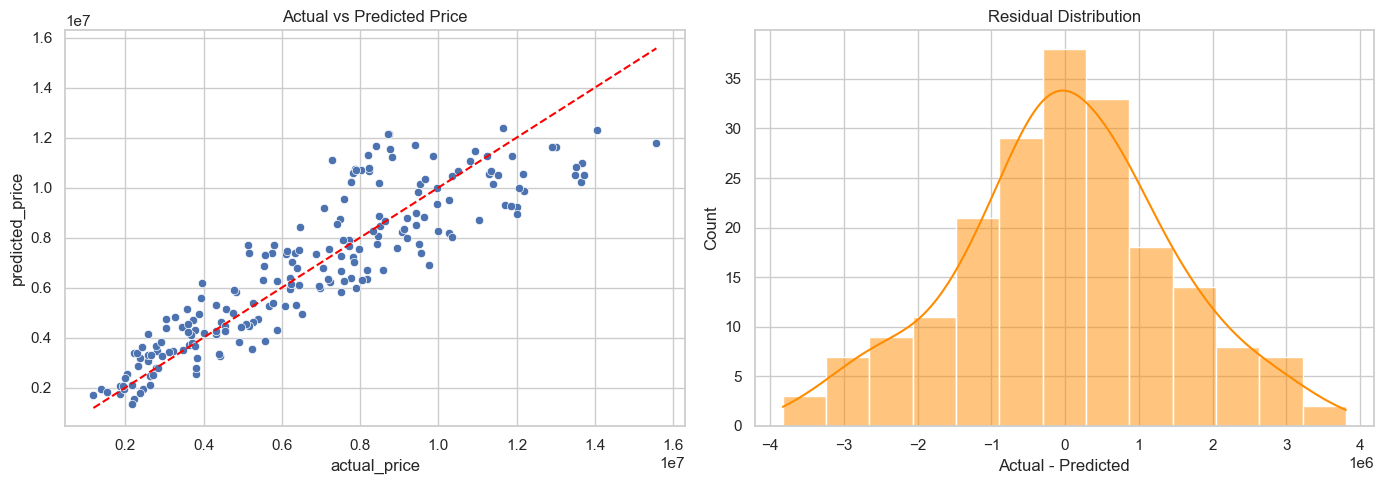

In [12]:
evaluation_df = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": y_pred,
    "error": y_test - y_pred,
    "absolute_error": np.abs(y_test - y_pred)
}).reset_index(drop=True)

display(evaluation_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=evaluation_df, x="actual_price", y="predicted_price", ax=axes[0])
axes[0].plot(
    [evaluation_df["actual_price"].min(), evaluation_df["actual_price"].max()],
    [evaluation_df["actual_price"].min(), evaluation_df["actual_price"].max()],
    color="red",
    linestyle="--"
)
axes[0].set_title("Actual vs Predicted Price")

sns.histplot(evaluation_df["error"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()

In [13]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = final_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
0,num__gaj,2.956172e+06,2.956172e+06
14,cat__location_Kavi Nagar Extension,-4.363652e+05,4.363652e+05
18,cat__location_Pilkhuwa Road,4.232546e+05,4.232546e+05
10,cat__location_Freeganj Road,4.184174e+05,4.184174e+05
4,num__age,-2.621732e+05,2.621732e+05
17,cat__location_Meerut Road,-2.480603e+05,2.480603e+05
1,num__bhk,2.396009e+05,2.396009e+05
26,cat__property_type_Villa,-2.328620e+05,2.328620e+05
12,cat__location_Garh Road,2.168739e+05,2.168739e+05
13,cat__location_Hapur Bypass,-2.049217e+05,2.049217e+05


In [14]:
new_house = pd.DataFrame([{
    "location": "Gandhi Ganj",
    "gaj": 152,
    "bhk": 4,
    "bath": 1,
    "balcony": 2,
    "age": 10,
    "floor": 4,
    "total_floor": 5,
    "property_type": "Villa",
    "furnishing": "Furnished"
}])

predicted_price = final_model.predict(new_house)[0]
print(f"Predicted price: {predicted_price:,.0f}")

Predicted price: 4,532,831


## Optional next steps

- Save the full fitted pipeline with `joblib.dump(final_model, "hapur_house_price_model.joblib")`.
- Add stronger feature engineering only after validating it with cross-validation.
- If you want to use target encoding for `location`, fit it only on training folds, never on the full dataset.